In [20]:
%load_ext cudf.pandas
import pandas as pd
import numpy as np
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import Sequential, layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping

The cudf.pandas extension is already loaded. To reload it, use:
  %reload_ext cudf.pandas


In [21]:
x = tf.random.normal((300000, 25))
y = tf.random.uniform((300000, 1))                  # regression based dataset

In [22]:
x = np.array(x).astype('float32') / 255.0
y = np.array(y).astype('float32')

In [23]:
from sklearn.model_selection import train_test_split as ttt

x_train, x_test, y_train, y_test = ttt(x,y, test_size=0.3, random_state=42)

print(x_train.shape)
print(x_test.shape)

(210000, 25)
(90000, 25)


In [28]:
import optuna

In [33]:
# STEP 1
def my_model(trial):
    # STEP 1.1
    dropouts = trial.suggest_float('dropout', 0.1, 0.4, step=0.05)

    layer_1 = trial.suggest_int('layer_1', 32, 128, step=16)
    layer_2 = trial.suggest_int('layer_2', 64, 256, step=32)
    layer_3 = trial.suggest_int('layer_3', 64, 256, step=16)
    layer_4 = trial.suggest_int('layer_4', 32, 128, step=16)
    layer_5 = trial.suggest_int('layer_5', 10, 15, step=5)

    activation_fn = trial.suggest_categorical('activation_fn', ['relu', 'leaky_relu', 'elu', 'tanh'])
    initializer = trial.suggest_categorical('initializer', ['glorot_normal', 'glorot_uniform', 'he_normal', 'he_uniform'])
    
    lr = trial.suggest_float('lr', 1e-4, 1e-1, log=True)
    SGD_momentum = trial.suggest_float('SGD_momentum', 0.3, 0.75)
    

    # STEP 1.2
    model = keras.Sequential([
        keras.Input(shape=(25,)),
        layers.Dense(layer_1, activation=activation_fn, kernel_initializer=initializer),
        layers.Dropout(dropouts),
        layers.Dense(layer_2, activation=activation_fn, kernel_initializer=initializer),
        layers.Dropout(dropouts),
        layers.Dense(layer_3, activation=activation_fn, kernel_initializer=initializer),
        layers.Dropout(dropouts),
        layers.Dense(layer_4, activation=activation_fn, kernel_initializer=initializer),
        layers.Dropout(dropouts),
        layers.Dense(layer_5, activation=activation_fn, kernel_initializer=initializer),
        layers.Dropout(dropouts),

        layers.Dense(1)
    ])


    # STEP 1.3
    model.compile(
        loss = keras.losses.MeanSquaredError(),
        optimizer = keras.optimizers.SGD(lr, momentum=SGD_momentum),
        metrics = ['mae']
    )

    # STEP 1.4
    early_stop = EarlyStopping(
        monitor = 'val_loss',
        patience = 5,
        restore_best_weights = True,
        verbose = 1
    ) 


    # STEP 1.5
    history = model.fit(
        x_train, y_train,
        callbacks = [early_stop],
        epochs = 5,
        validation_split = 0.2,
        verbose = 0
    )

    # STEP 1.6
    #  SAVING HISTORY DIRECTLY TO OPTUNA:
    trial.set_user_attr('train_loss', history.history['loss'])
    trial.set_user_attr('val_loss', history.history['val_loss'])
    trial.set_user_attr('train_mae', history.history['mae'])
    trial.set_user_attr('val_mae', history.history['val_mae'])
    
    best_val_loss = min(history.history['val_loss'])
    return best_val_loss


# STEP 2
study = optuna.create_study(direction='minimize')
study.optimize(my_model, n_trials = 3)

[I 2026-09-22 17:41:38,381] A new study created in memory with name: no-name-8c05561e-b64e-4ef2-8c66-00008b95813b


Restoring model weights from the end of the best epoch: 3.


[I 2026-09-22 17:42:51,185] Trial 0 finished with value: 0.08301395922899246 and parameters: {'dropout': 0.35, 'layer_1': 128, 'layer_2': 256, 'layer_3': 240, 'layer_4': 64, 'layer_5': 15, 'activation_fn': 'tanh', 'initializer': 'glorot_uniform', 'lr': 0.0069378964924845556, 'SGD_momentum': 0.3677103556975576}. Best is trial 0 with value: 0.08301395922899246.


Restoring model weights from the end of the best epoch: 1.


[I 2026-09-22 17:44:04,671] Trial 1 finished with value: 0.08298218250274658 and parameters: {'dropout': 0.35, 'layer_1': 48, 'layer_2': 160, 'layer_3': 256, 'layer_4': 112, 'layer_5': 10, 'activation_fn': 'relu', 'initializer': 'he_normal', 'lr': 0.003319751620714831, 'SGD_momentum': 0.4988947016323938}. Best is trial 1 with value: 0.08298218250274658.


Restoring model weights from the end of the best epoch: 4.


[I 2026-09-22 17:45:17,513] Trial 2 finished with value: 0.08306507021188736 and parameters: {'dropout': 0.2, 'layer_1': 128, 'layer_2': 192, 'layer_3': 256, 'layer_4': 128, 'layer_5': 15, 'activation_fn': 'relu', 'initializer': 'he_normal', 'lr': 0.055672806742804615, 'SGD_momentum': 0.48093476623569353}. Best is trial 1 with value: 0.08298218250274658.


In [34]:
import matplotlib.pyplot as plt

In [36]:
print(study.best_trial)
print()
print(study.best_params)


FrozenTrial(number=1, state=<TrialState.COMPLETE: 1>, values=[0.08298218250274658], datetime_start=datetime.datetime(2026, 9, 22, 17, 42, 51, 186063), datetime_complete=datetime.datetime(2026, 9, 22, 17, 44, 4, 671656), params={'dropout': 0.35, 'layer_1': 48, 'layer_2': 160, 'layer_3': 256, 'layer_4': 112, 'layer_5': 10, 'activation_fn': 'relu', 'initializer': 'he_normal', 'lr': 0.003319751620714831, 'SGD_momentum': 0.4988947016323938}, user_attrs={'train_loss': [0.08515820652246475, 0.0833122506737709, 0.08331537246704102, 0.08331169933080673, 0.08330882340669632], 'val_loss': [0.08298218250274658, 0.08301017433404922, 0.08302406966686249, 0.08300694823265076, 0.0829835757613182], 'train_mae': [0.25182095170021057, 0.24996992945671082, 0.2499772310256958, 0.24997198581695557, 0.2499610334634781], 'val_mae': [0.2491043508052826, 0.24913915991783142, 0.2491312474012375, 0.2491157054901123, 0.24909953773021698]}, system_attrs={}, intermediate_values={}, distributions={'dropout': FloatDis

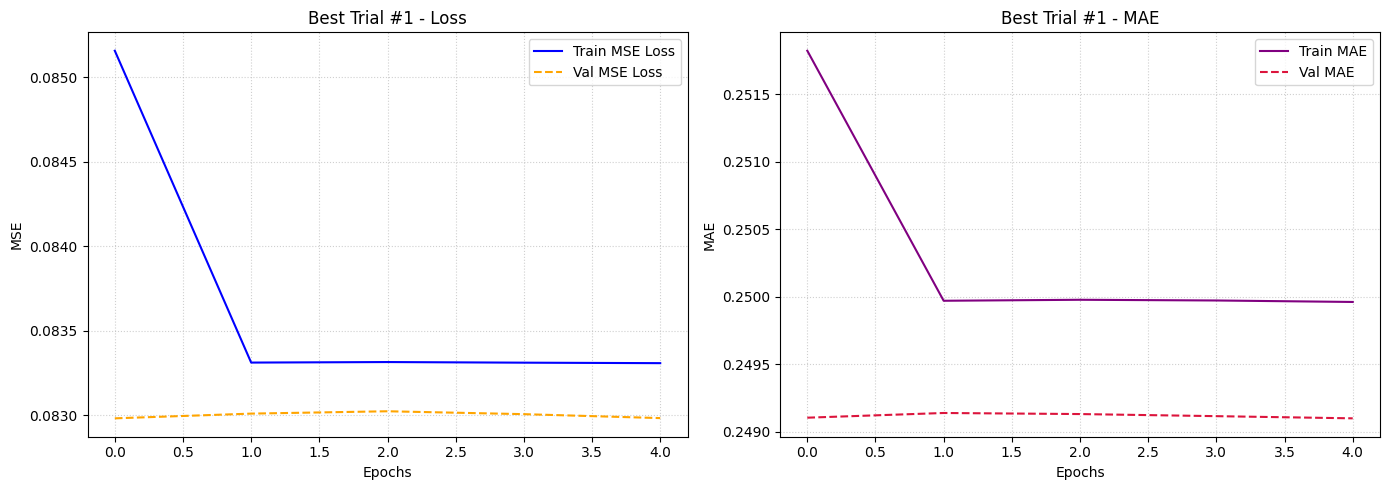

In [37]:
# 1. Grab the best trial from the study
best_trial = study.best_trial

# 2. Extract the saved history
train_loss = best_trial.user_attrs['train_loss']
val_loss   = best_trial.user_attrs['val_loss']
train_mae  = best_trial.user_attrs['train_mae']
val_mae    = best_trial.user_attrs['val_mae']

# 3. Plot with Matplotlib!
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Train MSE Loss', color='blue')
plt.plot(val_loss, label='Val MSE Loss', color='orange', linestyle='--')
plt.title(f"Best Trial #{best_trial.number} - Loss")
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Plot MAE
plt.subplot(1, 2, 2)
plt.plot(train_mae, label='Train MAE', color='purple')
plt.plot(val_mae, label='Val MAE', color='crimson', linestyle='--')
plt.title(f"Best Trial #{best_trial.number} - MAE")
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()